# <font style="color:rgb(50,120,229)">Edge Detection</font>

## <font style="color:rgb(50,120,229)"> Overview</font>

<center> <img src="https://www.learnopencv.com/wp-content/uploads/2017/12/opcv4face-w2-m2.3.3.png" width = 500/></center>

&nbsp;
Can you identify the animal in the above picture? Amazingly, everyone can. Even though the information in the above picture is many orders of magnitude less than the information contained in a picture of a dog, we can still easily say it is a dog. 

While processing images, we want to simplify the image so it is easier for vision and learning algorithms to process them. Edge detection provides such a simplification and it is therefore one of the most common low level operations in Computer Vision. 

In edge detection, given an image, we create a second, binary image which is dark (pixel value = 0) everywhere except on edges. For our purposes, edges will be defined as pixels with sharp intensity discontinuities.

## <font style="color:rgb(50,120,229)">Canny Edge Detection</font>

**Canny edge detection** is the most widely-used edge detector. For many of the applications that require edge detection, Canny edge detection is sufficient. 

Canny edge detection has the following three steps:

1. **Gradient calculations:**  Edges are pixels where intensity changes abruptly. From previous modules, we know that the magnitude of gradient is very high at edge pixels. Therefore, gradient calculation is the first step in Canny edge detection.

2. **Non-maxima suppression:** In the real world, the edges in an image are not sharp. The magnitude of gradient is very high not only at the real edge location, but also in a small neighborhood around it. Ideally, we want an edge to be represented by a single, pixel-thin contour. Simply thresholding the gradient leads to a fat contour that is several pixels thick.
      Fortunately, this problem can be eliminated by selecting the pixel with maximum gradient magnitude in a small neighborhood (say 3x3 neighborhood) of every pixel in the gradient image. The name non-maxima suppression comes from the fact that we eliminate (i.e. set to zero) all gradients except the maximum one in small 3x3 neighborhoods over the entire image.

3. **Hysteresis thresholding:** After non-maxima suppression, we could threshold the gradient image to obtain a new binary image which is black in all places except for pixels where the gradient is very high. This kind of thresholding would naively exclude a lot of edges because, in real world images, edges tend to fade in and out along their length. For example, an edge may be strong in the middle but fade out at the two ends.
      To fix this problem, Canny edge detection uses** **two thresholds. First, a higher threshold is used to select pixels with very high gradients. We say these pixels have a strong edge. Second, a lower threshold is used to obtain new pixels that are potential edge pixels. We say these pixels have a weak edge. A weak edge pixel can be re-classified as a strong edge if one of its neighbor is a strong edge. The weak edges that are not reclassified as strong are dropped from the final edge map. 

**<font style="color:rgb(255,0,0)">Note:</font>** According to Wikipedia, the word [hysteresis](https://en.wikipedia.org/wiki/Hysteresis) means "the dependence of the state of a system on its history." In thresholding, it is the dependence of the state ( edge / no edge ) of a pixel based on its neighbor. 

## <font style="color:rgb(50,120,229)">Canny Edge Detection in OpenCV</font>

The most common usage of [**`Canny`**](https://docs.opencv.org/4.1.0/dd/d1a/group__imgproc__feature.html#ga2a671611e104c093843d7b7fc46d24af) edge detector in OpenCV is shown below.

#### <font style="color:rgb(8,133,37)">Function Syntax</font>

```python
edges	=	cv.Canny(	dx, dy, threshold1, threshold2[, edges[, L2gradient]]	)
```

**Parameters**
- **`dx`**	16-bit x derivative of input image (CV_16SC1 or CV_16SC3).
- **`dy`**	16-bit y derivative of input image (same type as dx).
- **`edges`**	output edge map; single channels 8-bit image, which has the same size as image .
- **`threshold1`**	first threshold for the hysteresis procedure.
- **`threshold2`**	second threshold for the hysteresis procedure.
- **`L2gradient`**	a flag, indicating whether a more accurate L2 norm =√(dI/dx)2+(dI/dy)2 should be used to calculate the image gradient magnitude ( L2gradient=true ), or whether the default L1 norm =|dI/dx|+|dI/dy| is enough ( L2gradient=false ).

**If you want better accuracy at the expense of speed, you can set the L2gradient flag to true.**

**<font style="color:rgb(255,0,0)">Note:</font>** In the tutorial below, we have also included Gaussian blurring before edge detection. The amount of blur gives additional control over edge detection even though the Sobel operator implicitly blurs the image before gradient calculation. 

The tutorial below allows you to experiment with Canny edge detection parameters using trackbars. 

### <font style="color:rgb(8,133,37)">Python [Canny Edge Detection] [canny.py]</font>

In [10]:
import cv2
import numpy as np
from dataPath import DATA_PATH

The four parameters that you can control in this tutorial are:
+ lowTreshold
+ highTreshold
+ apertureSize (this takes values 3, 5 and 7 only)
+ blurAmount

In [11]:
lowThreshold = 50
highThreshold = 100

maxThreshold = 1000

apertureSizes = [3, 5, 7]
maxapertureIndex = 2
apertureIndex = 0

blurAmount = 0
maxBlurAmount = 20

The function applyCanny is called whenever any trackbar value is changed. The image is first blurred. The amount of blur depends on blurAmount. A Sobel apertureSize (3, 5 or 7) is chosen based on the trackbar value. Finally, the Canny function is called and results are displayed.

In [12]:
# Display images
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
# Function for all trackbar calls
def applyCanny():
    # Blur the image before edge detection
    if(blurAmount > 0):
        blurredSrc = cv2.GaussianBlur(src, 
                        (2 * blurAmount + 1, 2 * blurAmount + 1), 0);
    else:
        blurredSrc = src.copy()

    # Canny requires aperture size to be odd
    apertureSize = apertureSizes[apertureIndex];

    # Apply canny to detect the images
    edges = cv2.Canny( blurredSrc, 
                        lowThreshold, 
                        highThreshold, 
                        apertureSize = apertureSize )
    plt.imshow(edges[...,::-1])

This function is called when the lower threshold is changed

In [14]:
# Function to update low threshold value
def updateLowThreshold( *args ):
    global lowThreshold
    lowThreshold = args[0]
    applyCanny()
    pass

This function is called when the higher threshold is changed

In [15]:
# Function to update high threshold value
def updateHighThreshold( *args ):
    global highThreshold
    highThreshold = args[0]
    applyCanny()
    pass

This function is called when the blur amount is changed

In [16]:
# Function to update blur amount
def updateBlurAmount( *args ):
    global blurAmount
    blurAmount = args[0]
    applyCanny()
    pass

This function is called when the aperture size is changed

In [17]:
# Function to update aperture index
def updateApertureIndex( *args ):
    global apertureIndex
    apertureIndex = args[0]
    applyCanny()
    pass

Here, the image is read and trackbars are set to control the values of lowTreshold, highTreshold, apertureSize and blurAmount.

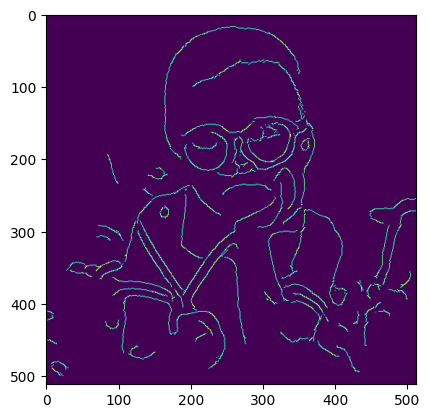

In [33]:
# Read sample image
src = cv2.imread(DATA_PATH + 'images/sample.jpg', cv2.IMREAD_GRAYSCALE)

edges = src.copy()
# Display images
cv2.namedWindow("Edges", cv2.WINDOW_AUTOSIZE)
cv2.imshow("Edges", src)
# Trackbar to control the low threshold
cv2.createTrackbar( "Low Threshold", "Edges", lowThreshold,
            maxThreshold, updateLowThreshold)
  
# Trackbar to control the high threshold
cv2.createTrackbar( "High Threshold", "Edges", highThreshold,
            maxThreshold, updateHighThreshold)
  
# Trackbar to control the aperture size
cv2.createTrackbar( "aperture Size", "Edges", apertureIndex,
            maxapertureIndex, updateApertureIndex)
  
# Trackbar to control the blur
cv2.createTrackbar( "Blur", "Edges", blurAmount, maxBlurAmount,
            updateBlurAmount)
k = cv2.waitKey(0)

if k == 27:
    cv2.destroyAllWindows()

## <font style="color:rgb(50,120,229)">Diving Deep into Canny Parameters</font>

If you play enough with the code provided in this section, you will notice the following about different parameters :

1. **lowThreshold :** Keeping all other parameters constant, when you lower the lowThreshold, broken edges tend to get connected. If you increase it, continuous edges may break. 

2. **highThreshold :** Keeping all other parameters constant, when you increase highThreshold, fewer edges are detected. On the other hand, decreasing highThreshold leads to more edges. 

3. **apertureSize :** Increasing the aperture size leads to many more edges. This is simply because larger Sobel kernels return larger gradient values. Low and high thresholds should be changed when aperture size is changed.

4. **blurAmount :** When the blur amount is increased, noise in the image is reduced, and spurious edges are removed. As a result, fewer edges are detected.
